## Setup the notebook. Importants and defining constants

In [34]:
import os
import math
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()} | MPS: {torch.backends.mps.is_available()}")

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Using device: {DEVICE}")

BASE = Path("Data")

TRAIN_ROOT = BASE / "Training"
DEV_ROOT   = BASE / "Development"
TEST_ROOT  = BASE / "Test"

BLACK_THRESHOLD     = 80
CAL_SPIKE_THRESHOLD = 25
LEFT_PCT            = 0.10
MIN_INTER_STRIP_GAP = 150
HEADER_GAP_RATIO    = 3.0
PADDING             = 20
COL_SPIKE_THRESHOLD = 50
MIN_CONSECUTIVE     = 5

LEAD_LAYOUT = {
    1: ["I",   "aVR", "V1", "V4"],
    2: ["II",  "aVL", "V2", "V5"],
    3: ["III", "aVF", "V3", "V6"],
    4: ["II"],
}
RHYTHM_STRIP_INDEX  = 4
SAMPLES_PER_LEAD    = 625
RHYTHM_SAMPLES      = 2500

IMG_H      = 283
IMG_W      = 512
EPOCHS     = 20
BATCH_SIZE = 32
LR         = 3e-4
BASE_CH    = 32

PyTorch 2.11.0 | CUDA: False | MPS: True
Using device: mps


## Preprocessing functions that are needed

In [35]:
def detect_signal_bands(img, target_bands=4):
    h, w = img.shape[:2]

    # Isolate left region where calibration pulse lives
    left = img[:, :int(w * LEFT_PCT)]
    b, g, r = cv2.split(left)
    black_mask = (r < BLACK_THRESHOLD) & (g < BLACK_THRESHOLD) & (b < BLACK_THRESHOLD)
    row_sums = black_mask.sum(axis=1).astype(float)

    # Subtract 1 to ignore the left border line
    row_sums = np.maximum(row_sums - 1, 0)
    spike_rows = np.where(row_sums > CAL_SPIKE_THRESHOLD)[0]

    # Group consecutive spike rows; take midpoint of each group as an anchor
    anchors = []
    if len(spike_rows) > 0:
        group_start = spike_rows[0]
        prev = spike_rows[0]
        for r_idx in spike_rows[1:]:
            if r_idx - prev > 5:
                anchors.append(int((group_start + prev) // 2))
                group_start = r_idx
            prev = r_idx
        anchors.append(int((group_start + prev) // 2))

    if len(anchors) < 2:
        return [(0, h)], anchors

    # Separate header anchors from signal anchors using gap ratio
    diffs = [anchors[i+1] - anchors[i] for i in range(len(anchors) - 1)]
    median_diff = np.median(diffs)
    header_cut = 0
    for i, d in enumerate(diffs):
        if d > median_diff * HEADER_GAP_RATIO:
            header_cut = i + 1
            break
    signal_anchors = anchors[header_cut:]

    # Merge anchors that are too close together
    strip_anchors = []
    prev = -MIN_INTER_STRIP_GAP
    for anchor in signal_anchors:
        if anchor - prev >= MIN_INTER_STRIP_GAP:
            strip_anchors.append(anchor)
            prev = anchor

    # Build band boundaries
    signal_bands = []
    for i, anchor in enumerate(strip_anchors):
        top = max(0, anchor - PADDING)
        bot = min(h, strip_anchors[i+1] - PADDING) if i+1 < len(strip_anchors) else h
        signal_bands.append((top, bot))

    # If too many bands, drop the shortest
    if len(signal_bands) > target_bands:
        ranked = sorted(signal_bands, key=lambda b: b[1] - b[0], reverse=True)
        kept = set(map(tuple, ranked[:target_bands]))
        signal_bands = [b for b in signal_bands if tuple(b) in kept]

    return signal_bands, strip_anchors

In [36]:
def split_ecg_strips(image_path, output_dir, target_bands=4):
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    signal_bands, _ = detect_signal_bands(img, target_bands=target_bands)
    os.makedirs(output_dir, exist_ok=True)
    stem = Path(image_path).stem
    saved = []
    for i, (y1, y2) in enumerate(signal_bands):
        out_path = os.path.join(output_dir, f"{stem}_strip_{i+1}.png")
        cv2.imwrite(out_path, img[y1:y2, :])
        saved.append(out_path)
    return saved

In [37]:
def find_split_points(strip):
    h, w = strip.shape[:2]
    b, g, r = cv2.split(strip)
    is_black = (r < BLACK_THRESHOLD) & (g < BLACK_THRESHOLD) & (b < BLACK_THRESHOLD)
    col_sums = is_black.sum(axis=0).astype(float)

    spike_cols = np.where(col_sums > 50)[0]

    # Group consecutive columns
    groups = []
    if len(spike_cols) > 0:
        group = [spike_cols[0]]
        for col in spike_cols[1:]:
            if col == group[-1] + 1:
                group.append(col)
            else:
                groups.append(group)
                group = [col]
        groups.append(group)

    # Filter obvious non-separators: borders, too narrow, too tall
    candidates = []
    for group in groups:
        width   = len(group)
        center  = int(np.mean(group))
        max_sum = col_sums[group].max()
        if width >= 4 and center > 10 and center < w - 10 and max_sum < 200:
            candidates.append((center, max_sum, width))

    if len(candidates) == 0:
        return []

    # We always expect 3 separators roughly evenly spaced at w/4, w/2, 3w/4
    # Score each candidate by how close it is to the expected positions
    expected = [w * 0.25, w * 0.50, w * 0.75]

    if len(candidates) >= 3:
        # Pick the best candidate for each expected position
        split_points = []
        used = set()
        for exp_x in expected:
            best = min(
                [c for i, c in enumerate(candidates) if i not in used],
                key=lambda c: abs(c[0] - exp_x)
            )
            idx = candidates.index(best)
            used.add(idx)
            split_points.append(best[0])
        return sorted(split_points)

    # Too few candidates — fall back to returning what we have
    return sorted([c[0] for c in candidates])

In [38]:
def split_strip_into_chunks(strip_path, mask_path, output_dir):
    strip_idx = int(strip_path.stem.split("_strip_")[1])
    if strip_idx == 4:
        return [], None  #strip 4 doesn't have the different chunks

    strip = cv2.imread(str(strip_path))
    mask  = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    split_points = find_split_points(strip)

    if len(split_points) != 3:
        return None, f"Expected 3 split points, got {len(split_points)}"

    os.makedirs(output_dir, exist_ok=True)
    stem   = Path(strip_path).stem
    bounds = [0] + split_points + [strip.shape[1]]
    saved  = []
    for i in range(len(bounds) - 1):
        x1, x2   = bounds[i], bounds[i+1]
        chunk    = mask[:, x1:x2]
        out_path = Path(output_dir) / f"{stem}_chunk_{i+1}.png"
        cv2.imwrite(str(out_path), chunk)
        saved.append(str(out_path))

    return saved, None

In [39]:
def crop_left_edge(chunk_path):
    """
    Crop the calibration square wave from the left edge of chunk 1.
    Overwrites the file in place. Only applies to chunk 1.
    """
    chunk_idx = int(chunk_path.stem.split("_chunk_")[-1])
    if chunk_idx != 1:
        return None, "Not chunk 1"

    chunk = cv2.imread(str(chunk_path))
    b, g, r = cv2.split(chunk)
    is_black = (r < BLACK_THRESHOLD) & (g < BLACK_THRESHOLD) & (b < BLACK_THRESHOLD)
    col_sums = is_black.sum(axis=0).astype(float)

    spike_cols = np.where(col_sums > 80)[0]
    if len(spike_cols) <= 3:
        return None, "Not enough spike cols"

    crop_point    = spike_cols[3]
    cropped_chunk = chunk[:, crop_point:]
    cv2.imwrite(str(chunk_path), cropped_chunk)
    return str(chunk_path), False


def crop_right_edge(chunk_path):
    """
    Crop blank space from the right edge.
    Applies to chunk 4 (outer right of strips 1-3) 
    and chunk 1 of strip 4 (rhythm strip).
    """
    chunk_idx = int(chunk_path.stem.split("_chunk_")[-1])
    strip_idx = int(chunk_path.stem.split("_strip_")[1].split("_")[0])
    
    is_outer_right  = (chunk_idx == 4)
    is_rhythm_strip = (strip_idx == 4 and chunk_idx == 1)
    
    if not is_outer_right and not is_rhythm_strip:
        return None, "Not chunk 4 or rhythm strip"

    chunk = cv2.imread(str(chunk_path))
    b, g, r = cv2.split(chunk)
    is_black = (r < BLACK_THRESHOLD) & (g < BLACK_THRESHOLD) & (b < BLACK_THRESHOLD)
    col_sums = is_black.sum(axis=0).astype(float)

    blank_cols = np.where(col_sums == 0)[0]

    groups = []
    if len(blank_cols) > 0:
        group = [blank_cols[0]]
        for col in blank_cols[1:]:
            if col == group[-1] + 1:
                group.append(col)
            else:
                if len(group) >= 25:
                    groups.append(group)
                group = [col]
        if len(group) >= 25:
            groups.append(group)

    if len(groups) == 0:
        return None, "No blank region found"

    crop_point    = groups[0][0]
    cropped_chunk = chunk[:, :crop_point]
    cv2.imwrite(str(chunk_path), cropped_chunk)
    return str(chunk_path), False

In [40]:
def preprocess_dataset(root, name):
    images_dir  = root / "Clean_Images"
    strips_dir  = root / "Strips"
    chunks_dir  = root / "Colour_Chunks"

    image_paths = sorted(list(images_dir.glob("*.png")) +
                         list(images_dir.glob("*.jpg")))
    print(f"\n{name}: {len(image_paths)} images found")

    # ── Step 1: Split strips ───────────────────────────────────────────────
    strips_dir.mkdir(parents=True, exist_ok=True)
    strip_errors = []
    for img_path in tqdm(image_paths, desc=f"{name} — splitting strips"):
        try:
            saved = split_ecg_strips(img_path, strips_dir)
            if len(saved) != 4:
                strip_errors.append((img_path.name, f"got {len(saved)} strips"))
        except Exception as e:
            strip_errors.append((img_path.name, str(e)))

    strip_paths = sorted(strips_dir.glob("*.png"))
    print(f"  Strips saved : {len(strip_paths)}")
    print(f"  Strip errors : {len(strip_errors)}")

    # ── Step 2: Split chunks ───────────────────────────────────────────────
    chunks_dir.mkdir(parents=True, exist_ok=True)
    chunk_errors  = []
    record_chunks = defaultdict(int)

    for strip_path in tqdm(strip_paths, desc=f"{name} — splitting chunks"):
        strip_idx = int(strip_path.stem.split("_strip_")[1])
        record_id = strip_path.stem.split("_Clean")[0]

        if strip_idx == RHYTHM_STRIP_INDEX:
            strip    = cv2.imread(str(strip_path))
            out_path = chunks_dir / f"{strip_path.stem}_chunk_1.png"
            cv2.imwrite(str(out_path), strip)
            record_chunks[record_id] += 1
            continue

        strip        = cv2.imread(str(strip_path))
        split_points = find_split_points(strip)

        if len(split_points) != 3:
            chunk_errors.append((strip_path.name, f"got {len(split_points)} split points"))
            continue

        bounds = [0] + split_points + [strip.shape[1]]
        for i in range(len(bounds) - 1):
            x1, x2  = bounds[i], bounds[i+1]
            chunk    = strip[:, x1:x2]
            out_path = chunks_dir / f"{strip_path.stem}_chunk_{i+1}.png"
            cv2.imwrite(str(out_path), chunk)
        record_chunks[record_id] += len(bounds) - 1

    print(f"  Chunk errors : {len(chunk_errors)}")

    # ── Step 3: Crop left and right edges ──────────────────────────────────
    all_chunks   = sorted(chunks_dir.glob("*.png"))
    crop_errors  = []
    left_cropped = right_cropped = 0

    for chunk_path in tqdm(all_chunks, desc=f"{name} — cropping edges"):
        # Left crop — chunk 1
        saved, err = crop_left_edge(chunk_path)
        if saved:
            left_cropped += 1
        elif err and err != "Not chunk 1":
            crop_errors.append((chunk_path.name, f"left: {err}"))

        # Right crop — chunk 4
        saved, err = crop_right_edge(chunk_path)
        if saved:
            right_cropped += 1
        elif err and err != "Not chunk 4 or rhythm strip":
            crop_errors.append((chunk_path.name, f"right: {err}"))

    print(f"  Left cropped : {left_cropped}")
    print(f"  Right cropped: {right_cropped}")
    print(f"  Crop errors  : {len(crop_errors)}")
    if crop_errors:
        for name_, err in crop_errors[:5]:
            print(f"    {name_}: {err}")
    

    # ── Summary ────────────────────────────────────────────────────────────
    counts = pd.Series(record_chunks.values())
    print(f"  Chunk distribution: {counts.value_counts().sort_index().to_dict()}")
    print(f"  Complete records (13 chunks): {(counts == 13).sum()}")

    return dict(record_chunks)

In [41]:
# ── Run preprocessing ──────────────────────────────────────────────────────
train_record_chunks = preprocess_dataset(TRAIN_ROOT, "Training")
dev_record_chunks   = preprocess_dataset(DEV_ROOT,   "Development")


Training: 600 images found


Training — splitting strips:   0%|          | 0/600 [00:00<?, ?it/s]

  Strips saved : 2400
  Strip errors : 0


Training — splitting chunks:   0%|          | 0/2400 [00:00<?, ?it/s]

  Chunk errors : 36


...

  Strips saved : 600
  Strip errors : 0


Development — splitting chunks:   0%|          | 0/600 [00:00<?, ?it/s]

  Chunk errors : 8


Development — cropping edges:   0%|          | 0/1922 [00:00<?, ?it/s]

  Left cropped : 570
  Right cropped: 592
  Crop errors  : 24
    1006867983_Clean_strip_1_chunk_1.png: left: Not enough spike cols
    1006867983_Clean_strip_1_chunk_4.png: right: No blank region found
    1531629157_Clean_strip_3_chunk_1.png: left: Not enough spike cols
    1678324396_Clean_strip_3_chunk_1.png: left: Not enough spike cols
    1868006986_Clean_strip_3_chunk_1.png: left: Not enough spike cols
  Chunk distribution: {9: 8, 13: 142}
  Complete records (13 chunks): 142


In [42]:
def build_index(root, record_chunks, name):
    """
    Build a DataFrame mapping every chunk to its lead and CSV path.
    Only includes complete records (13 chunks).
    """
    chunks_dir  = root / "Colour_Chunks"
    ts_dir      = root / "Timeseries"

    # Chunk index within each strip → lead name
    chunk_to_lead = {
        (1, 1): "I",   (1, 2): "aVR", (1, 3): "V1",  (1, 4): "V4",
        (2, 2): "aVL", (2, 3): "V2",  (2, 4): "V5",
        (3, 1): "III", (3, 2): "aVF", (3, 3): "V3",  (3, 4): "V6",
        (4, 1): "II",  # rhythm strip
    }

    rows = []
    for chunk_path in sorted(chunks_dir.glob("*.png")):
        stem      = chunk_path.stem
        record_id = stem.split("_Clean")[0]

        # Only include complete records
        if record_chunks.get(record_id, 0) != 13:
            continue

        csv_path = ts_dir / f"{record_id}.csv"
        if not csv_path.exists():
            continue

        strip_idx = int(stem.split("_strip_")[1].split("_")[0])
        chunk_idx = int(stem.split("_chunk_")[1])

        lead = chunk_to_lead.get((strip_idx, chunk_idx))
        if lead is None:
            continue

        # Rhythm strip outputs 2500 samples, all others 625
        output_len = RHYTHM_SAMPLES if strip_idx == RHYTHM_STRIP_INDEX else SAMPLES_PER_LEAD

        rows.append({
            "chunk_path": str(chunk_path),
            "lead":       lead,
            "record_id":  record_id,
            "csv_path":   str(csv_path),
            "strip_idx":  strip_idx,
            "chunk_idx":  chunk_idx,
            "output_len": output_len,
        })

    df = pd.DataFrame(rows)
    print(f"\n{name} index: {len(df)} samples")
    print(df["lead"].value_counts().sort_index())
    return df


train_index = build_index(TRAIN_ROOT, train_record_chunks, "Training")
dev_index   = build_index(DEV_ROOT,   dev_record_chunks,   "Development")


Training index: 6780 samples
lead
I      565
II     565
III    565
V1     565
V2     565
V3     565
V4     565
V5     565
V6     565
aVF    565
aVL    565
aVR    565
Name: count, dtype: int64

Development index: 1704 samples
lead
I      142
II     142
III    142
V1     142
V2     142
V3     142
V4     142
V5     142
V6     142
aVF    142
aVL    142
aVR    142
Name: count, dtype: int64


In [43]:
class ECGLeadDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df         = df.reset_index(drop=True)
        self.augment    = augment
        self._csv_cache = {}

    def __len__(self):
        return len(self.df)

    def _load_csv(self, path):
        if path not in self._csv_cache:
            self._csv_cache[path] = pd.read_csv(path)
        return self._csv_cache[path]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Image
        img = cv2.imread(row["chunk_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)
        img = img.astype(np.float32) / 255.0

        if self.augment:
            img = np.clip(img + np.random.uniform(-0.05, 0.05), 0, 1)

        img_tensor = torch.from_numpy(img).permute(2, 0, 1)  # [3, H, W]

        # Target
        output_len = row["output_len"]
        df_ts      = self._load_csv(row["csv_path"])
        lead       = row["lead"]

        # For lead II, select correct column based on strip
        if row["strip_idx"] == RHYTHM_STRIP_INDEX:
            ts_vals = df_ts[lead].dropna().values.astype(np.float32)
        else:
            ts_vals = df_ts[lead].dropna().values.astype(np.float32)

        if len(ts_vals) != output_len:
            ix      = np.linspace(0, len(ts_vals) - 1, output_len)
            ts_vals = np.interp(ix, np.arange(len(ts_vals)), ts_vals).astype(np.float32)

        return img_tensor, torch.from_numpy(ts_vals)


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=(1, 1)):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )
    def forward(self, x): return self.block(x)


class ECGEncoder(nn.Module):
    def __init__(self, base_ch=BASE_CH, in_ch=3):
        super().__init__()
        bc = base_ch
        self.net = nn.Sequential(
            ConvBlock(in_ch, bc,   stride=(2, 1)),
            ConvBlock(bc,   bc*2, stride=(2, 1)),
            ConvBlock(bc*2, bc*4, stride=(2, 1)),
            ConvBlock(bc*4, bc*8, stride=(2, 1)),
            ConvBlock(bc*8, bc*8, stride=(2, 1)),
            ConvBlock(bc*8, bc*8, stride=(2, 1)),
            ConvBlock(bc*8, bc*8, stride=(2, 1)),
            ConvBlock(bc*8, bc*8, stride=(2, 1)),
        )
        self.pool   = nn.AdaptiveAvgPool2d((1, None))
        self.out_ch = bc * 8

    def forward(self, x):
        x = self.net(x)
        x = self.pool(x)
        return x


class ECGDecoder(nn.Module):
    def __init__(self, in_ch, output_len):
        super().__init__()
        self.output_len = output_len
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, 128, kernel_size=5, padding=2), nn.GELU(),
            nn.Conv1d(128,    64, kernel_size=5, padding=2), nn.GELU(),
            nn.Conv1d(64,      1, kernel_size=5, padding=2),
        )

    def forward(self, x):
        x = x.squeeze(2)                                       # [B, C, W]
        x = self.net(x).squeeze(1)                             # [B, W]
        x = F.interpolate(x.unsqueeze(1), size=self.output_len,
                          mode='linear', align_corners=False).squeeze(1)
        return x


class ECGModel(nn.Module):
    def __init__(self, base_ch=BASE_CH, output_len=SAMPLES_PER_LEAD):
        super().__init__()
        self.encoder = ECGEncoder(base_ch, in_ch=3)
        self.decoder = ECGDecoder(self.encoder.out_ch, output_len)

    def forward(self, x):
        return self.decoder(self.encoder(x))


def ecg_loss(pred, target, grad_weight=2.0, peak_weight=5.0, smooth_weight=0.1):
    # Standard MSE
    mse = F.mse_loss(pred, target)
    
    # Gradient loss — penalize missing sharp changes
    grad_pred   = pred[:, 1:]   - pred[:, :-1]
    grad_target = target[:, 1:] - target[:, :-1]
    grad_loss   = F.mse_loss(grad_pred, grad_target)
    
    # Peak loss — weight errors at high amplitude regions more heavily
    amp_weight  = (target.abs() / (target.abs().max(dim=1, keepdim=True).values + 1e-8))
    peak_loss   = (amp_weight * (pred - target) ** 2).mean()
    
    # Smoothness loss — penalize second derivative of prediction
    smooth_loss = ((grad_pred[:, 1:] - grad_pred[:, :-1]) ** 2).mean()
    
    return mse + grad_weight * grad_loss + peak_weight * peak_loss + smooth_weight * smooth_loss


# Smoke test
_model  = ECGModel(output_len=SAMPLES_PER_LEAD).to(DEVICE)
_dummy  = torch.zeros(2, 3, IMG_H, IMG_W).to(DEVICE)
_out    = _model(_dummy)
_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f"Input : {_dummy.shape}")
print(f"Output: {_out.shape}  (expected [2, {SAMPLES_PER_LEAD}])")
print(f"Params: {_params:,}")

# Rhythm strip model
_model_r = ECGModel(output_len=RHYTHM_SAMPLES).to(DEVICE)
_out_r   = _model_r(_dummy)
print(f"Rhythm output: {_out_r.shape}  (expected [2, {RHYTHM_SAMPLES}])")

Input : torch.Size([2, 3, 283, 512])
Output: torch.Size([2, 625])  (expected [2, 625])
Params: 2,955,553
Rhythm output: torch.Size([2, 2500])  (expected [2, 2500])


In [44]:
def ecg_loss(pred, target, grad_weight=2.0, peak_weight=5.0, smooth_weight=0.1):
    mse         = F.mse_loss(pred, target)
    grad_pred   = pred[:, 1:]   - pred[:, :-1]
    grad_target = target[:, 1:] - target[:, :-1]
    grad_loss   = F.mse_loss(grad_pred, grad_target)
    amp_weight  = target.abs() / (target.abs().max(dim=1, keepdim=True).values + 1e-8)
    peak_loss   = (amp_weight * (pred - target) ** 2).mean()
    smooth_loss = ((grad_pred[:, 1:] - grad_pred[:, :-1]) ** 2).mean()
    return mse + grad_weight * grad_loss + peak_weight * peak_loss + smooth_weight * smooth_loss

In [45]:
def train_lead(lead, train_index, dev_index, output_len, epochs=EPOCHS):
    #Make sure we use the 2500 sample strip for lead II
    print(f"\n{'='*60}")
    print(f"Training lead: {lead}  |  output_len: {output_len}")
    print(f"{'='*60}")

    # Build datasets
    train_df = train_index[train_index["lead"] == lead].reset_index(drop=True)
    dev_df   = dev_index[dev_index["lead"] == lead].reset_index(drop=True)

    # For lead II, only use the non-rhythm strip rows for the 625-sample model
    # and only the rhythm strip rows for the 2500-sample model
    # if lead == "II":
    #     if output_len == SAMPLES_PER_LEAD:
    #         train_df = train_df[train_df["strip_idx"] != RHYTHM_STRIP_INDEX].reset_index(drop=True)
    #         dev_df   = dev_df[dev_df["strip_idx"]     != RHYTHM_STRIP_INDEX].reset_index(drop=True)
    #     else:
    #         train_df = train_df[train_df["strip_idx"] == RHYTHM_STRIP_INDEX].reset_index(drop=True)
    #         dev_df   = dev_df[dev_df["strip_idx"]     == RHYTHM_STRIP_INDEX].reset_index(drop=True)

    print(f"Train samples: {len(train_df)}  |  Dev samples: {len(dev_df)}")

    train_ds     = ECGLeadDataset(train_df, augment=True)
    dev_ds       = ECGLeadDataset(dev_df,   augment=False)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    dev_loader   = DataLoader(dev_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # Initialise model
    model     = ECGModel(base_ch=BASE_CH, output_len=output_len).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    CHECKPOINT_DIR = TRAIN_ROOT / "Checkpoints"
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

    best_val_loss  = float("inf")
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        train_loss = 0.0
        for imgs, targets in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False):
            imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)
            loss = ecg_loss(model(imgs), targets)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
        train_loss /= len(train_ds)

        # Validate on dev set
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, targets in dev_loader:
                imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)
                val_loss += ecg_loss(model(imgs), targets).item() * imgs.size(0)
        val_loss /= len(dev_ds)

        scheduler.step()
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"Epoch {epoch:3d} | train: {train_loss:.6f} | dev: {val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            ckpt_name     = f"best_model_{lead}_rhythm.pt" if output_len == RHYTHM_SAMPLES else f"best_model_{lead}.pt"
            torch.save({
                "epoch":       epoch,
                "model_state": model.state_dict(),
                "val_loss":    val_loss,
                "lead":        lead,
                "output_len":  output_len,
            }, CHECKPOINT_DIR / ckpt_name)
            print(f"  ✓ Saved (dev loss {val_loss:.6f})")

    print(f"\nLead {lead} done. Best dev loss: {best_val_loss:.6f}")
    return train_losses, val_losses, best_val_loss

In [46]:
def train_all_625(leads, train_index, dev_index, output_len, epochs=EPOCHS):
    print(f"\n{'='*60}")
    print(f"Training leads: {leads}  |  output_len: {output_len}")
    print(f"{'='*60}")

    # Build datasets
    train_df = train_index[train_index["lead"].isin(leads)].reset_index(drop=True)
    dev_df   = dev_index[dev_index["lead"].isin(leads)].reset_index(drop=True)

    print(f"Train samples: {len(train_df)}  |  Dev samples: {len(dev_df)}")

    train_ds     = ECGLeadDataset(train_df, augment=True)
    dev_ds       = ECGLeadDataset(dev_df,   augment=False)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    dev_loader   = DataLoader(dev_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # Initialise model
    model     = ECGModel(base_ch=BASE_CH, output_len=output_len).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    CHECKPOINT_DIR = TRAIN_ROOT / "Checkpoints"
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

    best_val_loss  = float("inf")
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        train_loss = 0.0
        for imgs, targets in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False):
            imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)
            loss = ecg_loss(model(imgs), targets)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
        train_loss /= len(train_ds)

        # Validate on dev set
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, targets in dev_loader:
                imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)
                val_loss += ecg_loss(model(imgs), targets).item() * imgs.size(0)
        val_loss /= len(dev_ds)

        scheduler.step()
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"Epoch {epoch:3d} | train: {train_loss:.6f} | dev: {val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            ckpt_name     = "best_model_all625.pt"
            torch.save({
                "epoch":       epoch,
                "model_state": model.state_dict(),
                "val_loss":    val_loss,
                "lead":        leads,
                "output_len":  output_len,
            }, CHECKPOINT_DIR / ckpt_name)
            print(f"  ✓ Saved (dev loss {val_loss:.6f})")

    print(f"\nLead {leads} done. Best dev loss: {best_val_loss:.6f}")
    return train_losses, val_losses, best_val_loss

In [47]:
leads_625  = ["I", "aVR", "V1", "V4", "aVL", "V2", "V5", "aVF", "V3", "V6", "III"]
train_losses_625, val_losses_625, best_625 = train_all_625(
        leads_625, train_index, dev_index, output_len=SAMPLES_PER_LEAD
    )


Training leads: ['I', 'aVR', 'V1', 'V4', 'aVL', 'V2', 'V5', 'aVF', 'V3', 'V6', 'III']  |  output_len: 625
Train samples: 6215  |  Dev samples: 1562


Epoch 1/20:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch   1 | train: 0.089163 | dev: 0.044296
  ✓ Saved (dev loss 0.044296)


Epoch 2/20:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch   2 | train: 0.075546 | dev: 0.025788
  ✓ Saved (dev loss 0.025788)


...

Epoch  18 | train: 0.042277 | dev: 0.019064
  ✓ Saved (dev loss 0.019064)


Epoch 19/20:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch  19 | train: 0.041298 | dev: 0.019154


Epoch 20/20:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch  20 | train: 0.040582 | dev: 0.018975
  ✓ Saved (dev loss 0.018975)

Lead ['I', 'aVR', 'V1', 'V4', 'aVL', 'V2', 'V5', 'aVF', 'V3', 'V6', 'III'] done. Best dev loss: 0.018975


Text(0.5, 1.0, 'All 625 Leads Model')

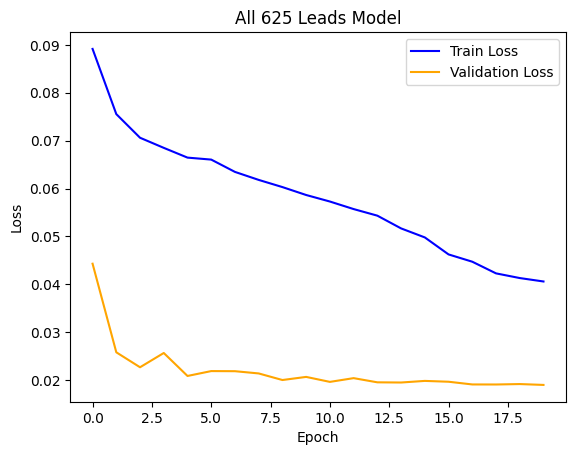

In [48]:
plt.plot(range(EPOCHS), train_losses_625, color = 'blue', label = "Train Loss")
plt.plot(range(EPOCHS), val_losses_625, color = 'orange', label = "Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("All 625 Leads Model")

In [49]:
# ── Train all leads ────────────────────────────────────────────────────────
CHECKPOINT_DIR = TRAIN_ROOT / "Checkpoints"
all_results    = {}

# All unique leads except II which needs special handling
leads_625  = ["I", "aVR", "V1", "V4", "aVL", "V2", "V5", "aVF", "V3", "V6", "III"]
for lead in leads_625:
    train_losses, val_losses, best = train_lead(
        lead, train_index, dev_index, output_len=SAMPLES_PER_LEAD
    )
    all_results[lead] = {"train": train_losses, "val": val_losses, "best": best}

# Rhythm strip (lead II, 2500 samples)
train_losses, val_losses, best = train_lead(
    "II", train_index, dev_index, output_len=RHYTHM_SAMPLES
)
all_results["II_rhythm"] = {"train": train_losses, "val": val_losses, "best": best}

# ── Summary ────────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("Training complete — summary:")
print(f"{'='*60}")
for lead, result in all_results.items():
    print(f"  {lead:10s}  best dev loss: {result['best']:.6f}")


Training lead: I  |  output_len: 625
Train samples: 565  |  Dev samples: 142


Epoch 1/20:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch   1 | train: 0.038737 | dev: 0.102235
  ✓ Saved (dev loss 0.102235)


Epoch 2/20:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch   2 | train: 0.012466 | dev: 0.028328
  ✓ Saved (dev loss 0.028328)


...

Epoch  18 | train: 0.008410 | dev: 0.007728


Epoch 19/20:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch  19 | train: 0.008361 | dev: 0.007664


Epoch 20/20:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch  20 | train: 0.008293 | dev: 0.007656
  ✓ Saved (dev loss 0.007656)

Lead II done. Best dev loss: 0.007656

Training complete — summary:
  I           best dev loss: 0.005425
  aVR         best dev loss: 0.003520
  V1          best dev loss: 0.028561
  V4          best dev loss: 0.079468
  aVL         best dev loss: 0.001387
  V2          best dev loss: 0.020632
  V5          best dev loss: 0.023412
  aVF         best dev loss: 0.005055
  V3          best dev loss: 0.011244
  V6          best dev loss: 0.014051
  III         best dev loss: 0.022594
  II_rhythm   best dev loss: 0.007656


Get mean of best dev losses

In [62]:
best_losses = []
for lead, result in all_results.items():
    print(f"  {lead:10s}  best dev loss: {result['best']:.6f}")
    if lead != "II_rhythm":
        best_losses.append(result['best'])

print(f"Average best dev loss: {np.mean(best_losses)}")

  I           best dev loss: 0.005425
  aVR         best dev loss: 0.003520
  V1          best dev loss: 0.028561
  V4          best dev loss: 0.079468
  aVL         best dev loss: 0.001387
  V2          best dev loss: 0.020632
  V5          best dev loss: 0.023412
  aVF         best dev loss: 0.005055
  V3          best dev loss: 0.011244
  V6          best dev loss: 0.014051
  III         best dev loss: 0.022594
  II_rhythm   best dev loss: 0.007656
Average best dev loss: 0.019577209023572743


In [50]:
# ── Step 1: Preprocess test set ────────────────────────────────────────────
TEST_ROOT  = BASE / "Testing"
test_record_chunks = preprocess_dataset(TEST_ROOT, "Test")


Test: 227 images found


Test — splitting strips:   0%|          | 0/227 [00:00<?, ?it/s]

  Strips saved : 908
  Strip errors : 0


Test — splitting chunks:   0%|          | 0/908 [00:00<?, ?it/s]

  Chunk errors : 6


Test — cropping edges:   0%|          | 0/2927 [00:00<?, ?it/s]

  Left cropped : 867
  Right cropped: 900
  Crop errors  : 37
    10140238_Clean_strip_3_chunk_1.png: left: Not enough spike cols
    1209416227_Clean_strip_3_chunk_1.png: left: Not enough spike cols
    1219936451_Clean_strip_3_chunk_1.png: left: Not enough spike cols
    1281093472_Clean_strip_4_chunk_1.png: right: No blank region found
    1441250561_Clean_strip_3_chunk_1.png: left: Not enough spike cols
  Chunk distribution: {9: 6, 13: 221}
  Complete records (13 chunks): 221


In [51]:
test_index = build_index(TEST_ROOT, test_record_chunks, "Test")
print(test_index["lead"].value_counts().sort_index())


Test index: 2652 samples
lead
I      221
II     221
III    221
V1     221
V2     221
V3     221
V4     221
V5     221
V6     221
aVF    221
aVL    221
aVR    221
Name: count, dtype: int64
lead
I      221
II     221
III    221
V1     221
V2     221
V3     221
V4     221
V5     221
V6     221
aVF    221
aVL    221
aVR    221
Name: count, dtype: int64


In [52]:
def evaluate_lead(lead, test_index, output_len, checkpoint_dir):
    """Evaluate one lead model on the test set."""
    ckpt_name = f"best_model_{lead}_rhythm.pt" if output_len == RHYTHM_SAMPLES else f"best_model_{lead}.pt"
    ckpt_path = checkpoint_dir / ckpt_name

    if not ckpt_path.exists():
        print(f"  ✗ Checkpoint not found: {ckpt_path}")
        return None

    # Load model
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)
    model = ECGModel(base_ch=BASE_CH, output_len=output_len).to(DEVICE)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    # Filter test index
    test_df = test_index[test_index["lead"] == lead].reset_index(drop=True)
    # if lead == "II":
    #     if output_len == SAMPLES_PER_LEAD:
    #         test_df = test_df[test_df["strip_idx"] != RHYTHM_STRIP_INDEX].reset_index(drop=True)
    #     else:
    #         test_df = test_df[test_df["strip_idx"] == RHYTHM_STRIP_INDEX].reset_index(drop=True)

    if len(test_df) == 0:
        print(f"  ✗ No test samples for {lead}")
        return None

    results = []
    for _, row in test_df.iterrows():
        img    = cv2.imread(row["chunk_path"])
        img    = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img    = cv2.resize(img, (IMG_W, IMG_H)).astype(np.float32) / 255.0
        tensor = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            pred = model(tensor).squeeze().cpu().numpy()

        df_ts = pd.read_csv(row["csv_path"])
        gt    = df_ts[row["lead"]].dropna().values.astype(np.float32)
        if len(gt) != output_len:
            ix = np.linspace(0, len(gt)-1, output_len)
            gt = np.interp(ix, np.arange(len(gt)), gt).astype(np.float32)

        results.append({
            "record_id": row["record_id"],
            "mse":       float(np.mean((pred - gt)**2)),
            "rmse":      float(np.sqrt(np.mean((pred - gt)**2))),
            "mae":       float(np.mean(np.abs(pred - gt))),
            "pred":      pred,
            "gt":        gt,
        })

    mse_vals  = [r["mse"]  for r in results]
    rmse_vals = [r["rmse"] for r in results]
    mae_vals  = [r["mae"]  for r in results]

    print(f"\n  Lead {lead:10s} | samples: {len(results):3d} | "
          f"MSE: {np.mean(mse_vals):.5f} | "
          f"RMSE: {np.mean(rmse_vals):.5f} | "
          f"MAE: {np.mean(mae_vals):.5f} | "
          f"Std: {np.std(mse_vals):.5f}")

    return results


# ── Evaluate all leads ─────────────────────────────────────────────────────
CHECKPOINT_DIR = TRAIN_ROOT / "Checkpoints"
test_results   = {}

print(f"\n{'='*60}")
print("Test Set Evaluation")
print(f"{'='*60}")

leads_625 = ["I", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]
for lead in leads_625:
    test_results[lead] = evaluate_lead(lead, test_index, SAMPLES_PER_LEAD, CHECKPOINT_DIR)

# Rhythm strip
test_results["II_rhythm"] = evaluate_lead("II", test_index, RHYTHM_SAMPLES, CHECKPOINT_DIR)

# ── Summary table ──────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("Summary")
print(f"{'='*60}")
rows = []
for lead, results in test_results.items():
    if results is None:
        continue
    mse_vals = [r["mse"]  for r in results]
    mae_vals = [r["mae"]  for r in results]
    rows.append({
        "Lead":      lead,
        "Samples":   len(results),
        "Mean MSE":  round(np.mean(mse_vals),  5),
        "Mean RMSE": round(np.sqrt(np.mean(mse_vals)), 5),
        "Mean MAE":  round(np.mean(mae_vals),  5),
        "Std MSE":   round(np.std(mse_vals),   5),
        "Best MSE":  round(np.min(mse_vals),   5),
        "Worst MSE": round(np.max(mse_vals),   5),
    })

summary_df = pd.DataFrame(rows).set_index("Lead")
print(summary_df.to_string())


Test Set Evaluation

  Lead I          | samples: 221 | MSE: 0.00122 | RMSE: 0.02642 | MAE: 0.01243 | Std: 0.00650

  Lead III        | samples: 221 | MSE: 0.00711 | RMSE: 0.05643 | MAE: 0.03386 | Std: 0.02206

  Lead aVR        | samples: 221 | MSE: 0.00078 | RMSE: 0.01765 | MAE: 0.01013 | Std: 0.00570

  Lead aVL        | samples: 221 | MSE: 0.00059 | RMSE: 0.01637 | MAE: 0.00787 | Std: 0.00245

  Lead aVF        | samples: 221 | MSE: 0.00125 | RMSE: 0.01697 | MAE: 0.00781 | Std: 0.00951

  Lead V1         | samples: 221 | MSE: 0.00385 | RMSE: 0.04656 | MAE: 0.03135 | Std: 0.01098

  Lead V2         | samples: 221 | MSE: 0.01441 | RMSE: 0.05848 | MAE: 0.03061 | Std: 0.09862

  Lead V3         | samples: 221 | MSE: 0.00295 | RMSE: 0.03733 | MAE: 0.01628 | Std: 0.01009

  Lead V4         | samples: 221 | MSE: 0.02301 | RMSE: 0.09696 | MAE: 0.05154 | Std: 0.08453

  Lead V5         | samples: 221 | MSE: 0.02895 | RMSE: 0.07104 | MAE: 0.03324 | Std: 0.22285

  Lead V6         | samples:

Evaluate all leads from the all-625 model

In [ ]:
def evaluate_lead_625model(lead, test_index, output_len, checkpoint_dir):
    """Evaluate the 625 model on the test set of one lead."""
    ckpt_name = "best_model_all625.pt"
    ckpt_path = checkpoint_dir / ckpt_name

    if not ckpt_path.exists():
        print(f"  ✗ Checkpoint not found: {ckpt_path}")
        return None

    # Load model
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)
    model = ECGModel(base_ch=BASE_CH, output_len=output_len).to(DEVICE)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    # Filter test index
    test_df = test_index[test_index["lead"] == lead].reset_index(drop=True)
    # if lead == "II":
    #     if output_len == SAMPLES_PER_LEAD:
    #         test_df = test_df[test_df["strip_idx"] != RHYTHM_STRIP_INDEX].reset_index(drop=True)
    #     else:
    #         test_df = test_df[test_df["strip_idx"] == RHYTHM_STRIP_INDEX].reset_index(drop=True)

    if len(test_df) == 0:
        print(f"  ✗ No test samples for {lead}")
        return None

    results = []
    for _, row in test_df.iterrows():
        img    = cv2.imread(row["chunk_path"])
        img    = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img    = cv2.resize(img, (IMG_W, IMG_H)).astype(np.float32) / 255.0
        tensor = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            pred = model(tensor).squeeze().cpu().numpy()

        df_ts = pd.read_csv(row["csv_path"])
        gt    = df_ts[row["lead"]].dropna().values.astype(np.float32)
        if len(gt) != output_len:
            ix = np.linspace(0, len(gt)-1, output_len)
            gt = np.interp(ix, np.arange(len(gt)), gt).astype(np.float32)

        results.append({
            "record_id": row["record_id"],
            "mse":       float(np.mean((pred - gt)**2)),
            "rmse":      float(np.sqrt(np.mean((pred - gt)**2))),
            "mae":       float(np.mean(np.abs(pred - gt))),
            "pred":      pred,
            "gt":        gt,
        })

    mse_vals  = [r["mse"]  for r in results]
    rmse_vals = [r["rmse"] for r in results]
    mae_vals  = [r["mae"]  for r in results]

    print(f"\n  Lead {lead:10s} | samples: {len(results):3d} | "
          f"MSE: {np.mean(mse_vals):.5f} | "
          f"RMSE: {np.mean(rmse_vals):.5f} | "
          f"MAE: {np.mean(mae_vals):.5f} | "
          f"Std: {np.std(mse_vals):.5f}")

    return results


# ── Evaluate all leads ─────────────────────────────────────────────────────
CHECKPOINT_DIR = TRAIN_ROOT / "Checkpoints"
test_results   = {}

print(f"\n{'='*60}")
print("Test Set Evaluation on Combined model")
print(f"{'='*60}")

leads_625 = ["I", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]
for lead in leads_625:
    test_results[lead] = evaluate_lead_625model(lead, test_index, SAMPLES_PER_LEAD, CHECKPOINT_DIR)

# Rhythm strip
test_results["II_rhythm"] = evaluate_lead("II", test_index, RHYTHM_SAMPLES, CHECKPOINT_DIR)

# ── Summary table ──────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("Summary")
print(f"{'='*60}")
rows = []
for lead, results in test_results.items():
    if results is None:
        continue
    mse_vals = [r["mse"]  for r in results]
    mae_vals = [r["mae"]  for r in results]
    rows.append({
        "Lead":      lead,
        "Samples":   len(results),
        "Mean MSE":  round(np.mean(mse_vals),  5),
        "Mean RMSE": round(np.sqrt(np.mean(mse_vals)), 5),
        "Mean MAE":  round(np.mean(mae_vals),  5),
        "Std MSE":   round(np.std(mse_vals),   5),
        "Best MSE":  round(np.min(mse_vals),   5),
        "Worst MSE": round(np.max(mse_vals),   5),
    })

summary_df = pd.DataFrame(rows).set_index("Lead")
print(summary_df.to_string())


Test Set Evaluation

  Lead I          | samples: 221 | MSE: 0.00138 | RMSE: 0.02873 | MAE: 0.01469 | Std: 0.00688

  Lead III        | samples: 221 | MSE: 0.01451 | RMSE: 0.06171 | MAE: 0.03472 | Std: 0.11194

  Lead aVR        | samples: 221 | MSE: 0.00084 | RMSE: 0.01942 | MAE: 0.01134 | Std: 0.00533

  Lead aVL        | samples: 221 | MSE: 0.00073 | RMSE: 0.02070 | MAE: 0.01054 | Std: 0.00206

  Lead aVF        | samples: 221 | MSE: 0.00154 | RMSE: 0.02532 | MAE: 0.01275 | Std: 0.00948

  Lead V1         | samples: 221 | MSE: 0.00310 | RMSE: 0.03263 | MAE: 0.01729 | Std: 0.01173

  Lead V2         | samples: 221 | MSE: 0.00926 | RMSE: 0.04921 | MAE: 0.02367 | Std: 0.05319

  Lead V3         | samples: 221 | MSE: 0.00319 | RMSE: 0.03955 | MAE: 0.01717 | Std: 0.01530

  Lead V4         | samples: 221 | MSE: 0.02089 | RMSE: 0.08084 | MAE: 0.03678 | Std: 0.08632

  Lead V5         | samples: 221 | MSE: 0.02010 | RMSE: 0.06316 | MAE: 0.02752 | Std: 0.17090

  Lead V6         | samples:

And from the individual models

In [ ]:
# ── Evaluate all leads ─────────────────────────────────────────────────────
CHECKPOINT_DIR = TRAIN_ROOT / "Checkpoints"
test_results   = {}

print(f"\n{'='*60}")
print("Test Set Evaluation on Individual Models")
print(f"{'='*60}")

leads_625 = ["I", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]
for lead in leads_625:
    test_results[lead] = evaluate_lead(lead, test_index, SAMPLES_PER_LEAD, CHECKPOINT_DIR)

# Rhythm strip
test_results["II_rhythm"] = evaluate_lead("II", test_index, RHYTHM_SAMPLES, CHECKPOINT_DIR)

# ── Summary table ──────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("Summary")
print(f"{'='*60}")
rows = []
for lead, results in test_results.items():
    if results is None:
        continue
    mse_vals = [r["mse"]  for r in results]
    mae_vals = [r["mae"]  for r in results]
    rows.append({
        "Lead":      lead,
        "Samples":   len(results),
        "Mean MSE":  round(np.mean(mse_vals),  5),
        "Mean RMSE": round(np.sqrt(np.mean(mse_vals)), 5),
        "Mean MAE":  round(np.mean(mae_vals),  5),
        "Std MSE":   round(np.std(mse_vals),   5),
        "Best MSE":  round(np.min(mse_vals),   5),
        "Worst MSE": round(np.max(mse_vals),   5),
    })

summary_df = pd.DataFrame(rows).set_index("Lead")
print(summary_df.to_string())


Test Set Evaluation

  Lead I          | samples: 221 | MSE: 0.00122 | RMSE: 0.02642 | MAE: 0.01243 | Std: 0.00650

  Lead III        | samples: 221 | MSE: 0.00711 | RMSE: 0.05643 | MAE: 0.03386 | Std: 0.02206

  Lead aVR        | samples: 221 | MSE: 0.00078 | RMSE: 0.01765 | MAE: 0.01013 | Std: 0.00570

  Lead aVL        | samples: 221 | MSE: 0.00059 | RMSE: 0.01637 | MAE: 0.00787 | Std: 0.00245

  Lead aVF        | samples: 221 | MSE: 0.00125 | RMSE: 0.01697 | MAE: 0.00781 | Std: 0.00951

  Lead V1         | samples: 221 | MSE: 0.00385 | RMSE: 0.04656 | MAE: 0.03135 | Std: 0.01098

  Lead V2         | samples: 221 | MSE: 0.01441 | RMSE: 0.05848 | MAE: 0.03061 | Std: 0.09862

  Lead V3         | samples: 221 | MSE: 0.00295 | RMSE: 0.03733 | MAE: 0.01628 | Std: 0.01009

  Lead V4         | samples: 221 | MSE: 0.02301 | RMSE: 0.09696 | MAE: 0.05154 | Std: 0.08453

  Lead V5         | samples: 221 | MSE: 0.02895 | RMSE: 0.07104 | MAE: 0.03324 | Std: 0.22285

  Lead V6         | samples:

Compare Val losses of the two models

In [63]:
CHECKPOINT_DIR = TRAIN_ROOT / "Checkpoints"
test_results   = {}

print(f"\n{'='*60}")
print("Dev Set Evaluation on Combined model")
print(f"{'='*60}")

leads_625 = ["I", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]
for lead in leads_625:
    test_results[lead] = evaluate_lead_625model(lead, dev_index, SAMPLES_PER_LEAD, CHECKPOINT_DIR)

# Rhythm strip
test_results["II_rhythm"] = evaluate_lead("II", dev_index, RHYTHM_SAMPLES, CHECKPOINT_DIR)

# ── Summary table ──────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("Summary")
print(f"{'='*60}")
rows = []
for lead, results in test_results.items():
    if results is None:
        continue
    mse_vals = [r["mse"]  for r in results]
    mae_vals = [r["mae"]  for r in results]
    rows.append({
        "Lead":      lead,
        "Samples":   len(results),
        "Mean MSE":  round(np.mean(mse_vals),  5),
        "Mean RMSE": round(np.sqrt(np.mean(mse_vals)), 5),
        "Mean MAE":  round(np.mean(mae_vals),  5),
        "Std MSE":   round(np.std(mse_vals),   5),
        "Best MSE":  round(np.min(mse_vals),   5),
        "Worst MSE": round(np.max(mse_vals),   5),
    })

summary_df = pd.DataFrame(rows).set_index("Lead")
print(summary_df.to_string())

print("Mean Dev Set Performance across leads:")
print(summary_df.mean().to_string())



Dev Set Evaluation on Combined model

  Lead I          | samples: 142 | MSE: 0.00114 | RMSE: 0.02862 | MAE: 0.01428 | Std: 0.00301

  Lead III        | samples: 142 | MSE: 0.00692 | RMSE: 0.05545 | MAE: 0.02743 | Std: 0.01868

  Lead aVR        | samples: 142 | MSE: 0.00097 | RMSE: 0.02046 | MAE: 0.01179 | Std: 0.00662

  Lead aVL        | samples: 142 | MSE: 0.00069 | RMSE: 0.02101 | MAE: 0.01034 | Std: 0.00132

  Lead aVF        | samples: 142 | MSE: 0.00156 | RMSE: 0.02596 | MAE: 0.01296 | Std: 0.00794

  Lead V1         | samples: 142 | MSE: 0.00739 | RMSE: 0.04225 | MAE: 0.02119 | Std: 0.03633

  Lead V2         | samples: 142 | MSE: 0.00363 | RMSE: 0.04057 | MAE: 0.01840 | Std: 0.01296

  Lead V3         | samples: 142 | MSE: 0.00354 | RMSE: 0.04209 | MAE: 0.01778 | Std: 0.01150

  Lead V4         | samples: 142 | MSE: 0.02060 | RMSE: 0.07997 | MAE: 0.03556 | Std: 0.09462

  Lead V5         | samples: 142 | MSE: 0.00562 | RMSE: 0.05168 | MAE: 0.02149 | Std: 0.01889

  Lead V6  

In [64]:
CHECKPOINT_DIR = TRAIN_ROOT / "Checkpoints"
test_results   = {}

print(f"\n{'='*60}")
print("Dev Set Evaluation on Individual model")
print(f"{'='*60}")

leads_625 = ["I", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]
for lead in leads_625:
    test_results[lead] = evaluate_lead(lead, dev_index, SAMPLES_PER_LEAD, CHECKPOINT_DIR)

# Rhythm strip
test_results["II_rhythm"] = evaluate_lead("II", dev_index, RHYTHM_SAMPLES, CHECKPOINT_DIR)

# ── Summary table ──────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("Summary")
print(f"{'='*60}")
rows = []
for lead, results in test_results.items():
    if results is None:
        continue
    mse_vals = [r["mse"]  for r in results]
    mae_vals = [r["mae"]  for r in results]
    rows.append({
        "Lead":      lead,
        "Samples":   len(results),
        "Mean MSE":  round(np.mean(mse_vals),  5),
        "Mean RMSE": round(np.sqrt(np.mean(mse_vals)), 5),
        "Mean MAE":  round(np.mean(mae_vals),  5),
        "Std MSE":   round(np.std(mse_vals),   5),
        "Best MSE":  round(np.min(mse_vals),   5),
        "Worst MSE": round(np.max(mse_vals),   5),
    })

summary_df = pd.DataFrame(rows).set_index("Lead")
print(summary_df.to_string())

print("Mean Dev Set Performance across leads:")
print(summary_df.mean().to_string())



Dev Set Evaluation on Individual model

  Lead I          | samples: 142 | MSE: 0.00130 | RMSE: 0.02719 | MAE: 0.01234 | Std: 0.00508

  Lead III        | samples: 142 | MSE: 0.00593 | RMSE: 0.05355 | MAE: 0.03031 | Std: 0.01485

  Lead aVR        | samples: 142 | MSE: 0.00091 | RMSE: 0.01848 | MAE: 0.01045 | Std: 0.00680

  Lead aVL        | samples: 142 | MSE: 0.00028 | RMSE: 0.01431 | MAE: 0.00716 | Std: 0.00038

  Lead aVF        | samples: 142 | MSE: 0.00136 | RMSE: 0.01724 | MAE: 0.00818 | Std: 0.01016

  Lead V1         | samples: 142 | MSE: 0.00823 | RMSE: 0.05685 | MAE: 0.03553 | Std: 0.03553

  Lead V2         | samples: 142 | MSE: 0.00521 | RMSE: 0.04884 | MAE: 0.02469 | Std: 0.02003

  Lead V3         | samples: 142 | MSE: 0.00241 | RMSE: 0.03568 | MAE: 0.01550 | Std: 0.00674

  Lead V4         | samples: 142 | MSE: 0.02189 | RMSE: 0.09402 | MAE: 0.05060 | Std: 0.09000

  Lead V5         | samples: 142 | MSE: 0.00586 | RMSE: 0.05181 | MAE: 0.02427 | Std: 0.02082

  Lead V6

In [55]:
import scipy.optimize
import scipy.signal
from typing import Tuple

# ── Paste the scoring functions exactly as provided ────────────────────────
LEADS = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
MAX_TIME_SHIFT = 0.2
PERFECT_SCORE  = 1e6

class ParticipantVisibleError(Exception):
    pass

def compute_power(label, prediction):
    if label.ndim != 1 or prediction.ndim != 1:
        raise ParticipantVisibleError('Inputs must be 1-dimensional arrays.')
    finite_mask = np.isfinite(prediction)
    if not np.any(finite_mask):
        raise ParticipantVisibleError("The 'prediction' array contains no finite values.")
    prediction[~np.isfinite(prediction)] = 0
    noise    = label - prediction
    p_signal = np.sum(label**2)
    p_noise  = np.sum(noise**2)
    return p_signal, p_noise

def compute_snr(signal, noise):
    if noise == 0:
        return PERFECT_SCORE
    elif signal == 0:
        return 0
    return min((signal / noise), PERFECT_SCORE)

def align_signals(label, pred, max_shift=float('inf')):
    if np.any(~np.isfinite(label)):
        raise ParticipantVisibleError('values in label should all be finite')
    if np.sum(np.isfinite(pred)) == 0:
        raise ParticipantVisibleError('prediction can not all be infinite')
    label_arr          = np.asarray(label, dtype=np.float64)
    pred_arr           = np.asarray(pred,  dtype=np.float64)
    label_arr_centered = label_arr - np.mean(label_arr)
    pred_arr_centered  = pred_arr  - np.mean(pred_arr)
    correlation        = scipy.signal.correlate(label_arr_centered, pred_arr_centered, mode='full')
    n_label, n_pred    = np.size(label_arr), np.size(pred_arr)
    lags               = scipy.signal.correlation_lags(n_label, n_pred, mode='full')
    valid_lags_mask    = (lags >= -max_shift) & (lags <= max_shift)
    max_correlation    = np.nanmax(correlation[valid_lags_mask])
    all_max_indices    = np.flatnonzero(correlation == max_correlation)
    best_idx           = min(all_max_indices, key=lambda i: abs(lags[i]))
    time_shift         = lags[best_idx]
    start_padding_len  = max(time_shift, 0)
    pred_slice_start   = max(-time_shift, 0)
    pred_slice_end     = min(n_label - time_shift, n_pred)
    end_padding_len    = max(n_label - n_pred - time_shift, 0)
    aligned_pred       = np.concatenate((
        np.full(start_padding_len, np.nan),
        pred_arr[pred_slice_start:pred_slice_end],
        np.full(end_padding_len, np.nan)
    ))
    def objective_func(v_shift):
        return np.nansum((label_arr - (aligned_pred - v_shift)) ** 2)
    if np.any(np.isfinite(label_arr) & np.isfinite(aligned_pred)):
        results        = scipy.optimize.minimize_scalar(objective_func, method='Brent')
        aligned_pred  -= results.x
    return aligned_pred

def _calculate_image_score(group):
    unique_fs_values = group['fs'].unique()
    if len(unique_fs_values) != 1:
        raise ParticipantVisibleError('Sampling frequency should be consistent across each ecg')
    sampling_frequency = unique_fs_values[0]
    if sampling_frequency != int(len(group[group['lead'] == 'II']) / 10):
        raise ParticipantVisibleError('The sequence_length should be sampling frequency * 10s')
    sum_signal = sum_noise = 0
    for lead in LEADS:
        sub   = group[group['lead'] == lead]
        label = sub['value_true'].values
        pred  = sub['value_pred'].values
        aligned_pred       = align_signals(label, pred, int(sampling_frequency * MAX_TIME_SHIFT))
        p_signal, p_noise  = compute_power(label, aligned_pred)
        sum_signal        += p_signal
        sum_noise         += p_noise
    return compute_snr(sum_signal, sum_noise)

def score(solution, submission, row_id_column_name):
    for df in [solution, submission]:
        if row_id_column_name not in df.columns:
            raise ParticipantVisibleError(f"'{row_id_column_name}' column not found.")
        if df['value'].isna().any():
            raise ParticipantVisibleError('NaN exists in solution/submission')
        if not np.isfinite(df['value']).all():
            raise ParticipantVisibleError('Infinity exists in solution/submission')
    submission = submission[['id', 'value']]
    merged_df  = pd.merge(solution, submission, on=row_id_column_name, suffixes=('_true', '_pred'))
    merged_df['image_id'] = merged_df[row_id_column_name].str.split('_').str[0]
    merged_df['row_id']   = merged_df[row_id_column_name].str.split('_').str[1].astype('int64')
    merged_df['lead']     = merged_df[row_id_column_name].str.split('_').str[2]
    merged_df.sort_values(by=['image_id', 'row_id', 'lead'], inplace=True)
    image_scores = merged_df.groupby('image_id').apply(_calculate_image_score, include_groups=False)
    return max(float(10 * np.log10(image_scores.mean())), -384)

print("Scoring functions loaded ✓")

Scoring functions loaded ✓


In [56]:
# ── Build solution and submission DataFrames ───────────────────────────────
# The id format is: {image_id}_{row_id}_{lead}
# image_id = record_id
# row_id   = sample index
# lead     = lead name
# fs       = sampling frequency (len(II_samples) / 10)

# We need all 12 leads per record — collect predictions and ground truth
# Use test_results for standard leads and test_results["II_rhythm"] for II

# First figure out which records are complete (have all 12 leads)
all_leads_standard = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]
leads_625 =  ["I", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

# Build lookup: record_id -> {lead -> {pred, gt}}
record_preds = defaultdict(dict)

for lead in leads_625:
    results = test_results.get(lead)
    if results is None:
        continue
    for r in results:
        record_preds[r["record_id"]][lead] = {"pred": r["pred"], "gt": r["gt"]}

# Add rhythm strip II (2500 samples) — overwrite the standard II
for r in test_results.get("II_rhythm", []):
    record_preds[r["record_id"]]["II_rhythm"] = {"pred": r["pred"], "gt": r["gt"]}

# Build DataFrames
solution_rows    = []
submission_rows  = []

# Sampling frequency: rhythm strip has 2500 samples over 10s → fs=250
# Standard leads have 625 samples → but II needs 2500 for the score function
# We use the rhythm strip II as the II lead for scoring
SCORING_FS = 250  # samples per second → II has 2500 samples = 250 * 10

skipped = 0
for record_id, leads_data in record_preds.items():
    # Check we have all 12 leads + rhythm II
    if not all(lead in leads_data for lead in leads_625):  # all except II
        skipped += 1
        continue
    if "II_rhythm" not in leads_data:
        skipped += 1
        continue

    for lead in all_leads_standard:
        if lead == "II":
            # Use rhythm strip for II (2500 samples)
            data    = leads_data["II_rhythm"]
            gt_vals = data["gt"]
            pr_vals = data["pred"]
        else:
            data    = leads_data[lead]
            gt_vals = data["gt"]
            pr_vals = data["pred"]

        for i, (gt_val, pr_val) in enumerate(zip(gt_vals, pr_vals)):
            row_id = i
            id_str = f"{record_id}_{row_id}_{lead}"
            solution_rows.append({"id": id_str, "fs": SCORING_FS, "value": float(gt_val),  "lead": lead})
            submission_rows.append({"id": id_str, "value": float(pr_val)})

solution_df   = pd.DataFrame(solution_rows)
submission_df = pd.DataFrame(submission_rows)

print(f"Records scored   : {len(record_preds) - skipped}")
print(f"Records skipped  : {skipped}")
print(f"Solution rows    : {len(solution_df)}")
print(f"Submission rows  : {len(submission_df)}")
print(f"\nSample solution rows:")
print(solution_df.head(3))

# ── Compute score ──────────────────────────────────────────────────────────
final_score = score(solution_df, submission_df, "id")
print(f"\n{'='*40}")
print(f"Final SNR Score: {final_score:.4f} dB")
print(f"{'='*40}")

Records scored   : 221
Records skipped  : 0
Solution rows    : 2071875
Submission rows  : 2071875

Sample solution rows:
               id   fs     value lead
0  1012423188_0_I  250  0.000000    I
1  1012423188_1_I  250 -0.005952    I
2  1012423188_2_I  250 -0.004048    I

Final SNR Score: 13.1515 dB


Repeat for the all 625 model

In [57]:


# ── Evaluate all leads ─────────────────────────────────────────────────────
CHECKPOINT_DIR = TRAIN_ROOT / "Checkpoints"
test_results   = {}

print(f"\n{'='*60}")
print("Test Set Evaluation")
print(f"{'='*60}")

leads_625 = ["I", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]
for lead in leads_625:
    test_results[lead] = evaluate_lead_625model(lead, test_index, SAMPLES_PER_LEAD, CHECKPOINT_DIR)

# Rhythm strip
test_results["II_rhythm"] = evaluate_lead("II", test_index, RHYTHM_SAMPLES, CHECKPOINT_DIR)

# ── Summary table ──────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("Summary")
print(f"{'='*60}")
rows = []
for lead, results in test_results.items():
    if results is None:
        continue
    mse_vals = [r["mse"]  for r in results]
    mae_vals = [r["mae"]  for r in results]
    rows.append({
        "Lead":      lead,
        "Samples":   len(results),
        "Mean MSE":  round(np.mean(mse_vals),  5),
        "Mean RMSE": round(np.sqrt(np.mean(mse_vals)), 5),
        "Mean MAE":  round(np.mean(mae_vals),  5),
        "Std MSE":   round(np.std(mse_vals),   5),
        "Best MSE":  round(np.min(mse_vals),   5),
        "Worst MSE": round(np.max(mse_vals),   5),
    })

summary_df = pd.DataFrame(rows).set_index("Lead")
print(summary_df.to_string())

# We need all 12 leads per record — collect predictions and ground truth
# Use test_results for standard leads and test_results["II_rhythm"] for II

# First figure out which records are complete (have all 12 leads)
all_leads_standard = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]
leads_625 =  ["I", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

# Build lookup: record_id -> {lead -> {pred, gt}}
record_preds = defaultdict(dict)

for lead in leads_625:
    results = test_results.get(lead)
    if results is None:
        continue
    for r in results:
        record_preds[r["record_id"]][lead] = {"pred": r["pred"], "gt": r["gt"]}

# Add rhythm strip II (2500 samples) — overwrite the standard II
for r in test_results.get("II_rhythm", []):
    record_preds[r["record_id"]]["II_rhythm"] = {"pred": r["pred"], "gt": r["gt"]}

# Build DataFrames
solution_rows    = []
submission_rows  = []

# Sampling frequency: rhythm strip has 2500 samples over 10s → fs=250
# Standard leads have 625 samples → but II needs 2500 for the score function
# We use the rhythm strip II as the II lead for scoring
SCORING_FS = 250  # samples per second → II has 2500 samples = 250 * 10

skipped = 0
for record_id, leads_data in record_preds.items():
    # Check we have all 12 leads + rhythm II
    if not all(lead in leads_data for lead in leads_625):  # all except II
        skipped += 1
        continue
    if "II_rhythm" not in leads_data:
        skipped += 1
        continue

    for lead in all_leads_standard:
        if lead == "II":
            # Use rhythm strip for II (2500 samples)
            data    = leads_data["II_rhythm"]
            gt_vals = data["gt"]
            pr_vals = data["pred"]
        else:
            data    = leads_data[lead]
            gt_vals = data["gt"]
            pr_vals = data["pred"]

        for i, (gt_val, pr_val) in enumerate(zip(gt_vals, pr_vals)):
            row_id = i
            id_str = f"{record_id}_{row_id}_{lead}"
            solution_rows.append({"id": id_str, "fs": SCORING_FS, "value": float(gt_val),  "lead": lead})
            submission_rows.append({"id": id_str, "value": float(pr_val)})

solution_df   = pd.DataFrame(solution_rows)
submission_df = pd.DataFrame(submission_rows)

print(f"Records scored   : {len(record_preds) - skipped}")
print(f"Records skipped  : {skipped}")
print(f"Solution rows    : {len(solution_df)}")
print(f"Submission rows  : {len(submission_df)}")
print(f"\nSample solution rows:")
print(solution_df.head(3))

# ── Compute score ──────────────────────────────────────────────────────────
final_score = score(solution_df, submission_df, "id")
print(f"\n{'='*40}")
print(f"Final SNR Score: {final_score:.4f} dB")
print(f"{'='*40}")


Test Set Evaluation

  Lead I          | samples: 221 | MSE: 0.00138 | RMSE: 0.02873 | MAE: 0.01469 | Std: 0.00688

  Lead III        | samples: 221 | MSE: 0.01451 | RMSE: 0.06171 | MAE: 0.03472 | Std: 0.11194

  Lead aVR        | samples: 221 | MSE: 0.00084 | RMSE: 0.01942 | MAE: 0.01134 | Std: 0.00533

  Lead aVL        | samples: 221 | MSE: 0.00073 | RMSE: 0.02070 | MAE: 0.01054 | Std: 0.00206

  Lead aVF        | samples: 221 | MSE: 0.00154 | RMSE: 0.02532 | MAE: 0.01275 | Std: 0.00948

  Lead V1         | samples: 221 | MSE: 0.00310 | RMSE: 0.03263 | MAE: 0.01729 | Std: 0.01173

  Lead V2         | samples: 221 | MSE: 0.00926 | RMSE: 0.04921 | MAE: 0.02367 | Std: 0.05319

  Lead V3         | samples: 221 | MSE: 0.00319 | RMSE: 0.03955 | MAE: 0.01717 | Std: 0.01530

  Lead V4         | samples: 221 | MSE: 0.02089 | RMSE: 0.08084 | MAE: 0.03678 | Std: 0.08632

  Lead V5         | samples: 221 | MSE: 0.02010 | RMSE: 0.06316 | MAE: 0.02752 | Std: 0.17090

  Lead V6         | samples: